In [7]:
from tensorflow.keras.layers import Conv2D
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from plotly import graph_objs as go

import tqdm

from src.green_gecko_model import CAModel, make_seed, get_living_mask, make_circle_masks
from src.lyapunov import lyapunov_spectrum, estimate_lyapunov_spectrum_tf, estimate_lyapunov

# Showing perturbations on version 1
### Load model

In [19]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

# Whether to scale the attractor or not
scale_attractor = False

In [9]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model/plain_salamander/big_fire_rate1/8000.weights.h5")
None

### Run model for a bit

In [10]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(3000):
    x = model(x)
    states.append(tf.identity(x).numpy())

states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end] #[:,:,10:-10,10:-10]
print(states_np.shape)

(3001, 1, 40, 40, 16)


### Flatten states and scale

In [11]:
flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)
timesteps = np.arange(flattened_attractor_states.shape[0])

if scale_attractor:
    scaler = StandardScaler()
    scaler = scaler.fit(flattened_attractor_states[2000:]) # originally 2000
    flattened_attractor_states_scaled = scaler.transform(flattened_attractor_states)

### Run on perturbations

  0%|          | 0/5 [00:00<?, ?it/s]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028648198..1.0252552].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10516197..1.2016616].
 20%|██        | 1/5 [00:06<00:24,  6.25s/it]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.074422196..1.0241605].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17213635..1.1374753].
 40%|████      | 2/5 [00:12<00:18,  6.12s/it]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028647942..1.0251813].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028647946..1.025

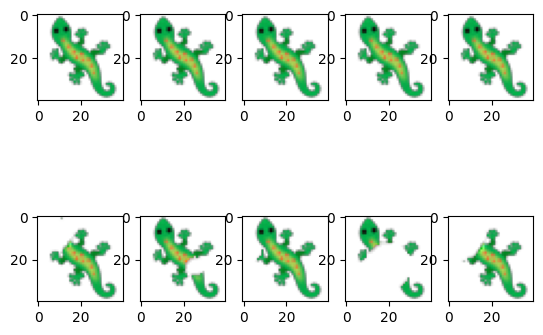

In [49]:
n_attractors = 5
big_perturb = True

perturb_recordings = []
perturb_recordings_not_flat = []

x = states[-1]

plt.figure()

for i in tqdm.trange(n_attractors):
    states_perturb = [tf.identity(x).numpy()]

    for iter in range(1500):
        x = model(x)
        states_perturb.append(tf.identity(x).numpy())

        if iter == 0:
            # add perturbation 
            if big_perturb:
                damage = 1.0-make_circle_masks(1, x.shape[1], x.shape[2]).numpy()[..., None]
                x = x.numpy()
                x *= damage
                x = tf.convert_to_tensor(x, dtype=tf.float32)
            elif not big_perturb:
                damage = tf.random.normal(x.shape, 0, 0.002)
                alive_mask = get_living_mask(x)
                x = x.numpy()
                x += damage * tf.cast(alive_mask, tf.float32)
                x = tf.convert_to_tensor(x, dtype=tf.float32)

    # Reset to the original attractor
    x = states[-1]
    
    states_perturb_np = np.stack(states_perturb)[:,:,x_start:x_end,y_start:y_end]

    flat_perturb = states_perturb_np.reshape(states_perturb_np.shape[0], -1)

    perturb_recordings.append(flat_perturb)
    perturb_recordings_not_flat.append(states_perturb_np)

    plt.subplot(2, n_attractors, i+1)
    plt.imshow(states_perturb_np[-1,0,...,:4])
    plt.subplot(2, n_attractors, n_attractors+i+1)
    plt.imshow(states_perturb_np[2,0,...,:4])

### PCA and scaling logic

In [ ]:
t_attractor_perturb = 1000
t_attractor_original = 1000

perturb_attractors = list(perturb_recordings[0][t_attractor_perturb:])

for flat_perturb in perturb_recordings[1:]:
    perturb_attractors += list(flat_perturb[t_attractor_perturb:])

print(len(perturb_attractors))

original_attractor = flattened_attractor_states[t_attractor_original:]
all_data = list(original_attractor) + perturb_attractors

if scale_attractor:
    scaler = StandardScaler()
    if big_perturb:
        scaler = scaler.fit(original_attractor)
    else:
        scaler = scaler.fit(all_data)
    scaled_all_data = scaler.transform(all_data)
    scaled_attractor = scaler.transform(original_attractor)


# Fit PCA
pca_transform = PCA(n_components=3)
if big_perturb:
    pca_transform = pca_transform.fit(
        original_attractor if not scale_attractor else scaled_attractor
    )
else:
    pca_transform = pca_transform.fit(
        all_data if not scale_attractor else scaled_all_data
    )

# Transform 
original_attractor_pca = pca_transform.transform(
    original_attractor if not scale_attractor else scaler.transform(original_attractor)
) 
add_paths = [
    pca_transform.transform(
        flat_perturb if not scale_attractor else 
        scaler.transform(flat_perturb)) for flat_perturb in perturb_recordings
    ]

2505


'original_attractor_pca = attractor_pca.transform(flattened_attractor_states[1000:] if not scale_attractor else scaler.transform(flattened_attractor_states[1000:])) #It was 1000 for non-stochastic\ntimesteps_from_2000 = np.arange(original_attractor_pca.shape[0])\n\nadd_paths = [attractor_pca.transform(flat_perturb if not scale_attractor else scaler.transform(flat_perturb)) for flat_perturb in perturb_recordings]'

### Then we plot

In [51]:
fig = go.Figure(data=go.Scatter3d(
    x=original_attractor_pca[:,0],
    y=original_attractor_pca[:,1],
    z=original_attractor_pca[:,2],
    mode='markers',
    marker=dict(
        size=2,
        opacity=1.0,
        colorscale="viridis",
        color=np.arange(0,len(original_attractor_pca))
    )

))

fig.update_traces(selector=dict(mode='markers'))

begin_n = 100 #Typically 2
for id, add_path in enumerate(add_paths):
    fig.add_scatter3d(
        x=add_path[begin_n:,0],
        y=add_path[begin_n:,1],
        z=add_path[begin_n:,2],
        mode='lines',
        line=dict(

            colorscale="plasma",
            color=np.arange(0,len(add_path[begin_n:]))
        )
    )

    fig.update_traces(selector=dict(mode='line'))

    fig.add_scatter3d(
        x=add_path[begin_n:begin_n+1,0],
        y=add_path[begin_n:begin_n+1,1],
        z=add_path[begin_n:begin_n+1,2],
        mode='markers',
        marker=dict(
            size=10,
            color=["black", "red", "green", "blue", "yellow"][id]
        )
    )

    fig.update_traces(selector=dict(mode='markers'))

# Update the layout to set width and height
fig.update_layout(
    autosize=False,
    width=1200,  # Set the desired width in pixels
    height=800, # Set the desired height in pixels
    margin=dict(l=50, r=50, b=100, t=100, pad=4), # Optional: adjust margins
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    )
)

fig.show()

### Plot one perturbation attractor

In [54]:
scaled_perturbation = StandardScaler().fit_transform(perturb_recordings[-4][500:])
print(scaled_perturbation.shape)
pca_perturbation = PCA(n_components=3).fit_transform(scaled_perturbation)
print(pca_perturbation.shape)

fig = go.Figure(data=go.Scatter3d(
    x=pca_perturbation[:,0],
    y=pca_perturbation[:,1],
    z=pca_perturbation[:,2],
    mode='markers',
    marker=dict(
        size=2,
        opacity=1.0,
        colorscale="plasma",
        color=np.arange(0,len(pca_perturbation))
    )

))

fig.update_traces(selector=dict(mode='markers'))

fig.add_scatter3d(
    x=pca_perturbation[:,0],
    y=pca_perturbation[:,1],
    z=pca_perturbation[:,2],
    mode='lines',
    line=dict(
        colorscale="plasma",
        color=np.arange(0,len(pca_perturbation))
    )
)

fig.update_traces(selector=dict(mode='lines'))

fig.update_layout(
    autosize=False,
    width=1200,  # Set the desired width in pixels
    height=800, # Set the desired height in pixels
    margin=dict(l=50, r=50, b=100, t=100, pad=4), # Optional: adjust margins
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    )
)

(1001, 25600)
(1001, 3)


### Calculate distances for all points on unscaled data

In [73]:
mean_pos_original = original_attractor.mean(axis=0)

for i in range(n_attractors):
    mean_pos_perturb = perturb_recordings[i][1000:].mean(axis=0)
    print(f"Perturbation {i} is", np.linalg.norm(mean_pos_original - mean_pos_perturb), "away from the original")

print()

for i in range(n_attractors):
    for j in range(i+1,n_attractors):
        mean_pos_perturb_i = perturb_recordings[i][1000:].mean(axis=0)
        mean_pos_perturb_j = perturb_recordings[j][1000:].mean(axis=0)
        print(f"Perturbation {i} is", np.linalg.norm(mean_pos_perturb_j - mean_pos_perturb_i), "away from perturbation", j)

Perturbation 0 is 0.31057757 away from the original
Perturbation 1 is 2.3773494 away from the original
Perturbation 2 is 0.00087365886 away from the original
Perturbation 3 is 0.6143692 away from the original
Perturbation 4 is 0.000872864 away from the original

Perturbation 0 is 2.3978047 away from perturbation 1
Perturbation 0 is 0.3105745 away from perturbation 2
Perturbation 0 is 0.5300893 away from perturbation 3
Perturbation 0 is 0.31057116 away from perturbation 4
Perturbation 1 is 2.3773575 away from perturbation 2
Perturbation 1 is 2.4556994 away from perturbation 3
Perturbation 1 is 2.3773682 away from perturbation 4
Perturbation 2 is 0.61436844 away from perturbation 3
Perturbation 2 is 0.00023544545 away from perturbation 4
Perturbation 3 is 0.61436665 away from perturbation 4
